<a href="https://colab.research.google.com/github/Mayankmishra15/crop_yield_pridiction/blob/main/crop_yield_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()   # upload crop_yield.csv


Saving crop_yield.csv to crop_yield.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
df = pd.read_csv("crop_yield.csv")
df.head()


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


for checking missing values & data structure


In [ ]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


,0
Crop,0
Crop_Year,0
Season,0
State,0
Area,0
Production,0
Annual_Rainfall,0
Fertilizer,0
Pesticide,0
Yield,0


In [ ]:
df.duplicates().sum()

# **EDA**

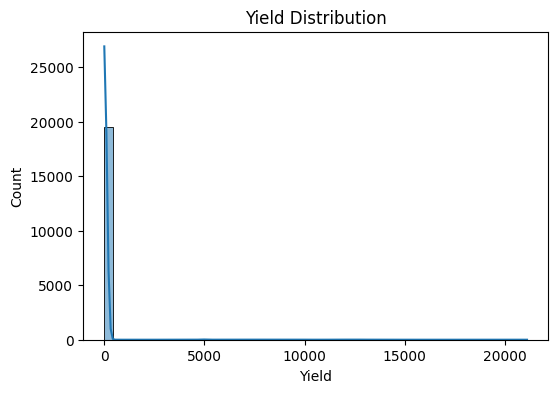

In [ ]:
#YIELD DISTRIBUTION
plt.figure(figsize=(6,4))
sns.histplot(df['Yield'], bins=50, kde=True)
plt.title("Yield Distribution")
plt.show()


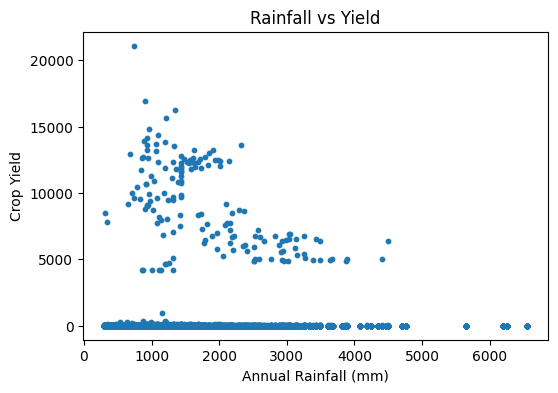

In [ ]:
# Rainfall vs yield
plt.figure(figsize=(6,4))
plt.scatter(df['Annual_Rainfall'], df['Yield'], s=10)
plt.xlabel("Annual Rainfall (mm)")
plt.ylabel("Crop Yield")
plt.title("Rainfall vs Yield")
plt.show()


In [ ]:
# choose rice for detection
#CROP_NAME = "Rice"
#df_crop = df[df['Crop'] == CROP_NAME].copy()
#df_crop.shape


In [ ]:
df = df.sort_values(["State","Crop", "Crop_Year"]).reset_index(drop=True)
df['Fert_per_Area'] =df['Fertilizer']/(df['Area']+1e-9)
df['Pest_per_Area'] =df['Pesticide']/(df['Area']+1e-9)
df['Rain_per_Area'] =df['Annual_Rainfall']/(df['Area']+1e-9)
df['Total_Input'] = df['Fertilizer'] + df['Pesticide']
df['Prod_per_fert'] = df['Production'] / (df['Fertilizer']+1e-9)
df['Crop_Age'] = 2024 - df['Crop_Year']
df['Yield_lag1'] = df.groupby(['State', 'Crop'])['Yield'].shift(1)
df['Yield_lag2'] = df.groupby(['State', 'Crop'])['Yield'].shift(2)

# Seasonal average yield
df['Seasonal_Avg_Yield'] = df.groupby('Season')['Yield'].transform('mean')

# Drop rows where lag features are NaN (first year per group)
df = df.dropna(subset=['Yield_lag1', 'Yield_lag2']).reset_index(drop=True)

print('Features after engineering:', df.shape)

df.head()




Features after engineering: (17727, 19)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Fert_per_Area,Pest_per_Area,Rain_per_Area,Total_Input,Prod_per_fert,Crop_Age,Yield_lag1,Yield_lag2,Seasonal_Avg_Yield
0,Arecanut,2002,Whole Year,Andhra Pradesh,296.0,427,648.1,28022.32,74.00,1.4525,94.67,0.25,2.189527,28096.32,0.015238,22,1.7100,2.7800,412.995463
1,Arecanut,2003,Whole Year,Andhra Pradesh,311.0,221,826.0,30782.78,74.64,0.7040,98.98,0.24,2.655949,30857.42,0.007179,21,1.4525,1.7100,412.995463
2,Arecanut,2005,Whole Year,Andhra Pradesh,293.0,234,1075.5,35136.56,61.53,0.8025,119.92,0.21,3.670648,35198.09,0.006660,19,0.7040,1.4525,412.995463
3,Arecanut,2006,Whole Year,Andhra Pradesh,255.0,176,845.2,32566.05,56.10,0.6850,127.71,0.22,3.314510,32622.15,0.005404,18,0.8025,0.7040,412.995463
4,Arecanut,2008,Whole Year,Andhra Pradesh,359.0,265,944.6,51351.36,32.31,0.9150,143.04,0.09,2.631198,51383.67,0.005161,16,0.6850,0.8025,412.995463


In [ ]:
# create lag feature
#df_crop["Yield_lag1"] = df_crop.groupby("State")["Yield"].shift(1)
#df_crop = df_crop.dropna(subset=["Yield_lag1"])
#df_crop.head()



In [ ]:
features = [
    'Crop_Year', 'Season', 'State', 'Crop',
    'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide',
    'Fert_per_Area', 'Pest_per_Area', 'Rain_per_Area',
    'Total_Input', 'Prod_per_fert', 'Crop_Age',
    'Yield_lag1', 'Yield_lag2', 'Seasonal_Avg_Yield'
]

X = df[features].copy()
y_raw = df['Yield']

# FIX #2: Log-transform the heavily skewed target
# Original: y = df['Yield']  ← no transform, causes large RMSE
y = np.log1p(y_raw)

# Encode categorical columns
X = pd.get_dummies(X, columns=['Season', 'State', 'Crop'], drop_first=True)

print('Feature matrix shape:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Keep raw y_test for final evaluation after inverse transform
y_test_raw = y_raw.loc[y_test.index]

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')


Feature matrix shape: (17727, 102)
Train: 14181 rows | Test: 3546 rows


In [ ]:
# Scale features (needed for Linear Regression and CNN)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate(name, y_true_log, y_pred_log):
    """Inverse-transform predictions back to original scale, then compute metrics."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 0, None)   # no negative yields

    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f'\n{name}')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    return {'Model': name, 'R2_Score': r2, 'MAE': mae, 'RMSE': rmse,
            'y_pred': y_pred}

results = []

In [ ]:
 # linear regression
 # model training
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
# prediction
y_pred_lr = lr.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_lr)
r2_dt = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("RMSE:", rmse_dt)
print("MAE :", mae_dt)
print("R²  :", r2_dt)



Linear Regression Results
RMSE: 0.11822433598687813
MAE : 0.2562697336852663
R²  : 0.862497340036295


In [ ]:
# decision tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("RMSE:", rmse_dt)
print("MAE :", mae_dt)
print("R²  :", r2_dt)


Decision Tree Results
RMSE: 0.11822433598687813
MAE : 0.06371883177360113
R²  : 0.9893792466038905


In [ ]:
# random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features = 'sqrt',
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("RMSE:", rmse_rf)
print("MAE :", mae_rf)
print("R²  :", r2_rf)


Random Forest Results
RMSE: 0.15587377163061383
MAE : 0.0863006585101973
R²  : 0.9815376216732046


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf],
    "MAE": [mae_lr, mae_dt, mae_rf],
    "R2_Score": [r2_lr, r2_dt, r2_rf]
})

print(results)


               Model      RMSE       MAE  R2_Score
0  Linear Regression  0.425388  0.256270  0.862497
1      Decision Tree  0.118224  0.063719  0.989379
2      Random Forest  0.155874  0.086301  0.981538


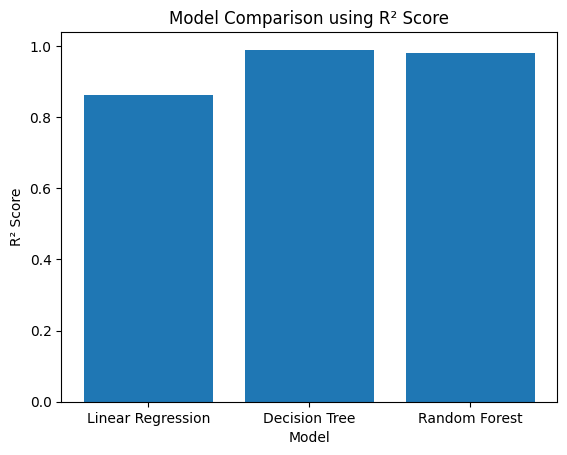

In [ ]:
# barchart for r^2 score
import matplotlib.pyplot as plt

plt.bar(results["Model"], results["R2_Score"])
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Comparison using R² Score")
plt.show()


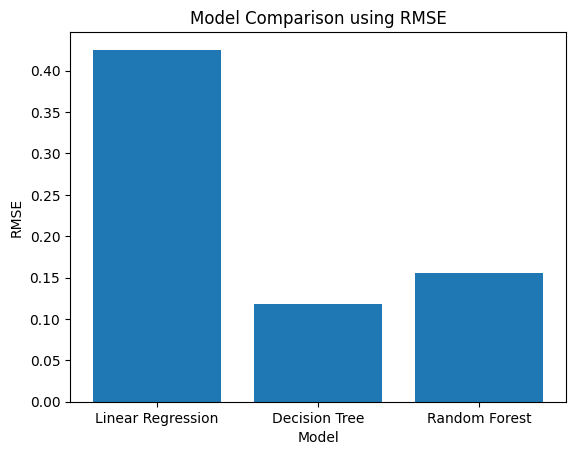

In [ ]:
#barchart for rmse
plt.bar(results["Model"], results["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison using RMSE")
plt.show()


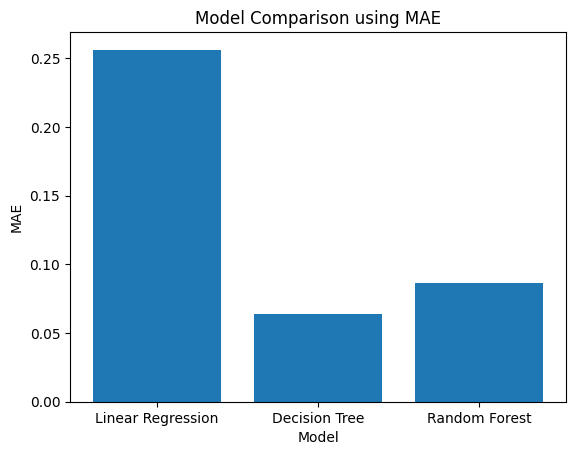

In [ ]:
plt.bar(results["Model"], results["MAE"])
plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison using MAE")
plt.show()

In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=15,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)
# testing
y_pred_xgb = xgb.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Test Results")
print("RMSE:", rmse_xgb)
print("MAE :", mae_xgb)
print("R²  :", r2_xgb)




XGBoost Test Results
RMSE: 0.10079843855935762
MAE : 0.05001209268616402
R²  : 0.9922794335118955


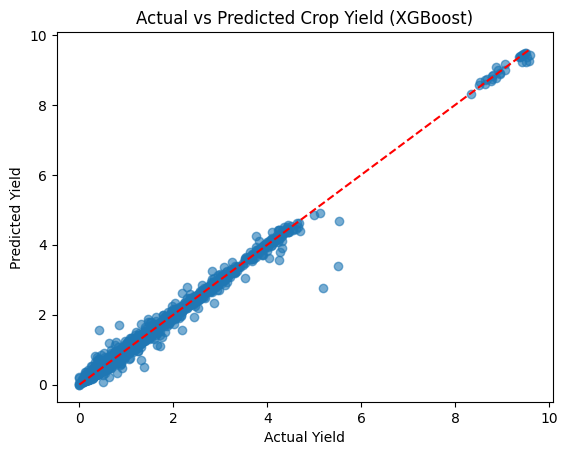

In [ ]:
plt.scatter(y_test, y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield (XGBoost)")
plt.show()


In [ ]:
y_test_pred_xgb = xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
mae = mean_absolute_error(y_test, y_test_pred_xgb)
r2 = r2_score(y_test, y_test_pred_xgb)

print("Final XGBoost Test Results")
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)


Final XGBoost Test Results
RMSE: 0.10079843855935762
MAE : 0.05001209268616402
R²  : 0.9922794335118955


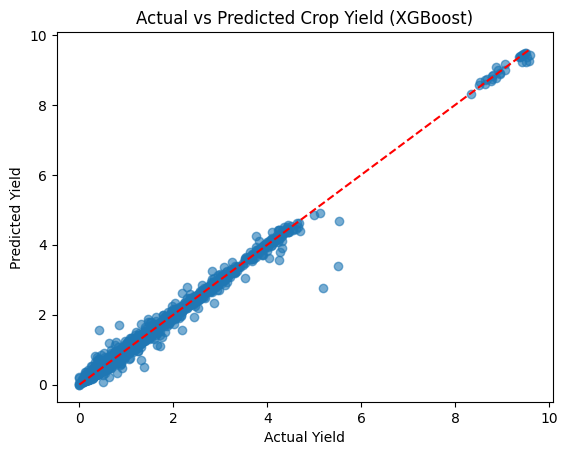

In [ ]:
plt.scatter(y_test, y_test_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield (XGBoost)")
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
X_train_cnn = X_train_sc.reshape(X_train_sc.shape[0], X_train_sc.shape[1], 1)
X_test_cnn  = X_test_sc.reshape(X_test_sc.shape[0],  X_test_sc.shape[1],  1)

print('CNN input shape:', X_train_cnn.shape)

tf.random.set_seed(42)
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)    # regression output
])

cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,                  # more patience than original (10)
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=150,                   # increased from 100
    batch_size=64,                # increased from 32 (faster, more stable)
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

y_pred_cnn = cnn_model.predict(X_test_cnn, verbose=0).flatten()
rmse_cnn = np.sqrt(mean_squared_error(y_test, y_pred_cnn))
mae_cnn = mean_absolute_error(y_test, y_pred_cnn)
r2_cnn = r2_score(y_test, y_pred_cnn)

print("CNN Test Results")
print("RMSE:", rmse_cnn)
print("MAE :", mae_cnn)
print("R²  :", r2_cnn)



CNN input shape: (14181, 102, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 100, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 48, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 426,625 (1.63 MB)

 Trainable params: 426,625 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 0.4059 - val_loss: 0.1817
Epoch 2/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.2173 - val_loss: 0.1310
Epoch 3/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.1845 - val_loss: 0.1811
Epoch 4/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.1583 - val_loss: 0.1071
Epoch 5/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.1573 - val_loss: 0.1079
Epoch 6/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.1366 - val_loss: 0.1124
Epoch 7/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.1377 - val_loss: 0.0731
Epoch 8/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.1226 - val_loss: 0.0834
Epoch 9/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.1169 - val_loss: 0.0731
Epoch 10/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.1184 - val_loss: 0.0706
Epoch 11/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.1048 - val_loss: 0.0694
Epoch 12/150
200/200 ━━━━━━━

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        " CNN "
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_xgb,
        rmse_cnn
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_xgb,
        mae_cnn
    ],
    "R2_Score": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_xgb,
        r2_cnn
    ]
})

print(results)

               Model      RMSE       MAE  R2_Score
0  Linear Regression  0.425388  0.256270  0.862497
1      Decision Tree  0.118224  0.063719  0.989379
2      Random Forest  0.155874  0.086301  0.981538
3            XGBoost  0.100798  0.050012  0.992279
4               CNN   0.226031  0.134428  0.961178


In [ ]:
best_model = results.loc[results["R2_Score"].idxmax()]
print("Best Model Based on R² Score:")
print(best_model)

Best Model Based on R² Score:
Model        XGBoost
RMSE        0.100798
MAE         0.050012
R2_Score    0.992279
Name: 3, dtype: object


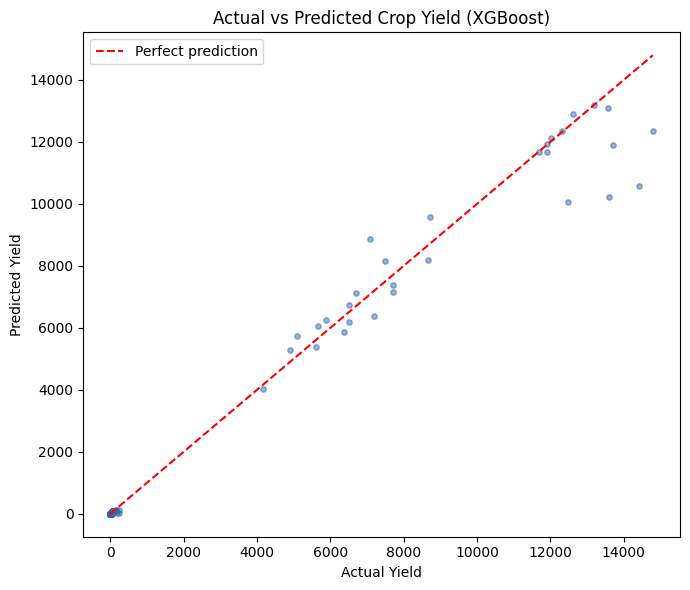

In [ ]:
y_pred_best = np.expm1(y_pred_xgb)
y_true_best = np.expm1(y_test.values)

plt.figure(figsize=(7, 6))
plt.scatter(y_true_best, y_pred_best, alpha=0.5, s=15, color='#3266ad')
lo, hi = y_true_best.min(), y_true_best.max()
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Actual vs Predicted Crop Yield (XGBoost)')
plt.legend()
plt.tight_layout()
plt.show()

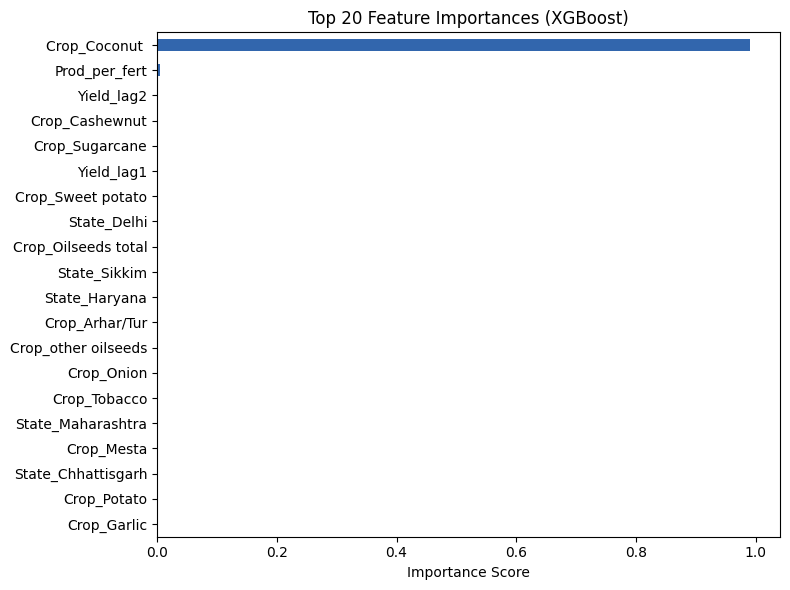

In [ ]:
importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
top20 = importances.nlargest(20)

plt.figure(figsize=(8, 6))
top20.sort_values().plot(kind='barh', color='#3266ad')
plt.title('Top 20 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(xgb, "crop_yield_model.pkl")


['crop_yield_model.pkl']

In [ ]:
joblib.dump(X_train.columns, "feature_columns.pkl")


['feature_columns.pkl']

In [ ]:
import joblib

# Save trained model (xgb or rf, whichever you finalized)
joblib.dump(xgb, "crop_yield_model.pkl")

# Save feature columns
joblib.dump(X_train.columns, "feature_columns.pkl")

print("Model and feature columns saved successfully")


Model and feature columns saved successfully


In [ ]:
import os

print(os.path.getsize("crop_yield_model.pkl"))
print(os.path.getsize("feature_columns.pkl"))


2635862
1160


In [ ]:
from google.colab import files

files.download("crop_yield_model.pkl")
files.download("feature_columns.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Scale features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# CNN expects 3D input: (samples, timesteps, features)
# We treat each feature as a "timestep" with 1 channel
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn  = X_test_scaled.reshape(X_test_scaled.shape[0],  X_test_scaled.shape[1],  1)

print("CNN input shape:", X_train_cnn.shape)
# e.g. (952, 39, 1)  → 952 samples, 39 features, 1 channel

CNN input shape: (933, 40, 1)


In [ ]:
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)          # regression output
])

cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True)

history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 544)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        34,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,377 (161.63 KB)

 Trainable params: 41,377 (161.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 1.7197 - val_loss: 0.6145
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.5237 - val_loss: 0.3503
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3322 - val_loss: 0.2510
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2969 - val_loss: 0.2390
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2515 - val_loss: 0.1774
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2448 - val_loss: 0.2333
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2357 - val_loss: 0.1553
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2434 - val_loss: 0.1367
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2010 - val_loss: 0.1368
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2113 - val_loss: 0.1481
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2224 - val_loss: 0.1304
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - los

In [ ]:
y_pred_cnn = cnn_model.predict(X_test_cnn).flatten()

rmse_cnn = np.sqrt(mean_squared_error(y_test, y_pred_cnn))
mae_cnn  = mean_absolute_error(y_test, y_pred_cnn)
r2_cnn   = r2_score(y_test, y_pred_cnn)

print("CNN Results")
print("RMSE:", rmse_cnn)
print("MAE :", mae_cnn)
print("R²  :", r2_cnn)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
CNN Results
RMSE: 0.4363495739392252
MAE : 0.2498563010601407
R²  : 0.7160046630030832


            Model     RMSE      MAE  R2_Score
          XGBoost 0.369057 0.215234  0.796844
    Random Forest 0.415628 0.236153  0.742337
              CNN 0.436350 0.249856  0.716005
Linear Regression 0.478920 0.274827  0.657889
    Decision Tree 0.481689 0.312009  0.653921

Best Model: XGBoost
R²: 0.7968443372876112


/tmp/ipykernel_3590/575354880.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(models, rotation=20, ha='right')
/tmp/ipykernel_3590/575354880.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(models, rotation=20, ha='right')
/tmp/ipykernel_3590/575354880.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(models, rotation=20, ha='right')


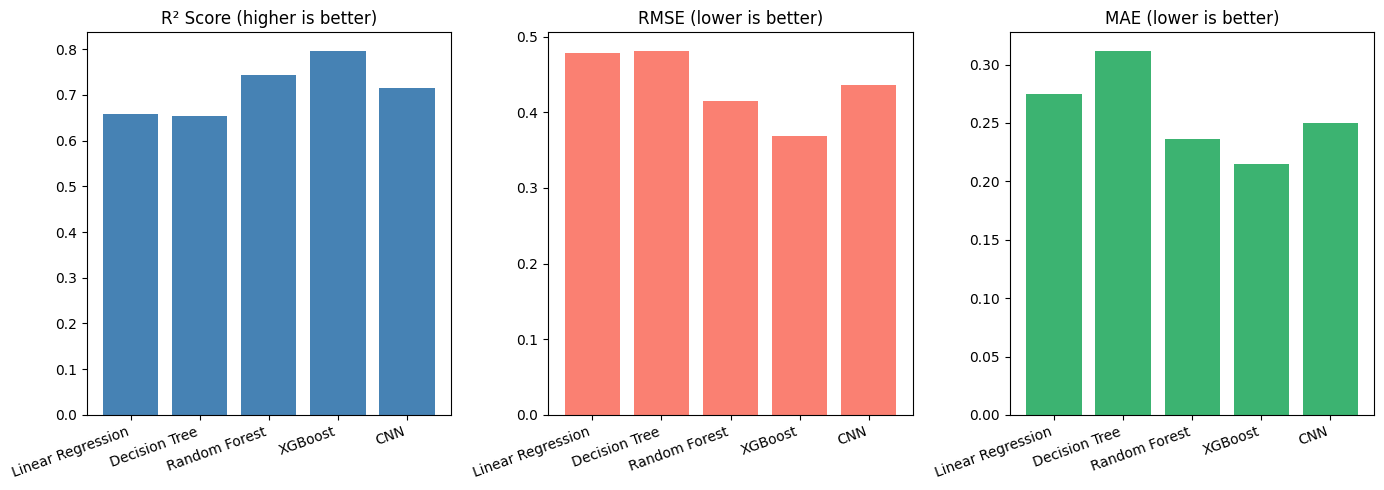

In [ ]:
results_all = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree",
              "Random Forest", "XGBoost", "CNN"],
    "RMSE":     [rmse_lr, rmse_dt, rmse_rf, rmse_xgb, rmse_cnn],
    "MAE":      [mae_lr,  mae_dt,  mae_rf,  mae_xgb,  mae_cnn],
    "R2_Score": [r2_lr,   r2_dt,   r2_rf,   r2_xgb,   r2_cnn]
})

print(results_all.sort_values("R2_Score", ascending=False).to_string(index=False))

best = results_all.loc[results_all["R2_Score"].idxmax()]
print("\nBest Model:", best["Model"])
print("R²:", best["R2_Score"])

# Comparison chart
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
models = results_all["Model"]

axes[0].bar(models, results_all["R2_Score"], color='steelblue')
axes[0].set_title("R² Score (higher is better)")
axes[0].set_xticklabels(models, rotation=20, ha='right')

axes[1].bar(models, results_all["RMSE"], color='salmon')
axes[1].set_title("RMSE (lower is better)")
axes[1].set_xticklabels(models, rotation=20, ha='right')

axes[2].bar(models, results_all["MAE"], color='mediumseagreen')
axes[2].set_title("MAE (lower is better)")
axes[2].set_xticklabels(models, rotation=20, ha='right')

plt.tight_layout()
plt.show()

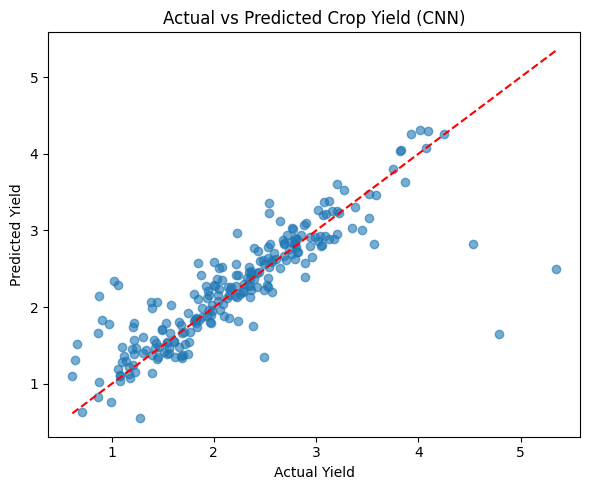

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_cnn, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield (CNN)")
plt.tight_layout()
plt.show()